# Análise Exploratória de Dados (EDA)

Este notebook realiza análises descritivas sobre os dados estruturados de influenciadores.
Ele reflete a nova arquitetura de camadas do processamento:

- **`base_2017_2019`**: Para análises descritivas gerais. Não exclui zeros nos comentários para evitar viés.
- **`core_2017_2019`**: Para análises de robustez e estabilidade, com os zeros excluídos.

## 1. Configuração

In [21]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr, pearsonr

In [2]:
# Caminhos
DIRETORIO = Path("bases-processadas/")

PARQUET_BASE_COMPLETA = f"{DIRETORIO}/posts_base_completa.parquet"
PARQUET_BASE_2017_2019 = f"{DIRETORIO}/posts_base_2017_2019.parquet"
PARQUET_CORE_2017_2019 = f"{DIRETORIO}/posts_core_2017_2019.parquet"


PARQUET_CV_BASE = f"{DIRETORIO}/cv_base_2017_2019.parquet"
PARQUET_CV_ANUAL_BASE = f"{DIRETORIO}/cv_base_anual.parquet"

PARQUET_CV_CORE = f"{DIRETORIO}/cv_core_2017_2019.parquet"
PARQUET_CV_ANUAL_CORE = f"{DIRETORIO}/cv_core_anual.parquet"

ORDEM_BUCKET = ['nano', 'micro', 'mid-tier', 'macro', 'mega']

## 2. Carga das Bases

In [3]:
base = pl.read_parquet(PARQUET_BASE_2017_2019)
core = pl.read_parquet(PARQUET_CORE_2017_2019)
cv_base  = pl.read_parquet(PARQUET_CV_BASE)
cv_core  = pl.read_parquet(PARQUET_CV_CORE)
cv_anual_base = pl.read_parquet(PARQUET_CV_ANUAL_BASE)
cv_anual_core = pl.read_parquet(PARQUET_CV_ANUAL_CORE)


print(f"Base principal (2017-2019):  {base.shape}")
print(f"Core (comments_count > 0):   {core.shape}")
print(f"CV base (nível de perfil):   {cv_base.shape}")
print(f"CV core (nível de perfil):   {cv_core.shape}")
print(f"CV anual base:               {cv_anual_base.shape}")
print(f"CV anual core:               {cv_anual_core.shape}")

Base principal (2017-2019):  (8897233, 32)
Core (comments_count > 0):   (825268, 32)
CV base (nível de perfil):   (33127, 6)
CV core (nível de perfil):   (32646, 6)
CV anual base:               (84113, 6)
CV anual core:               (59302, 6)


## 3. Perfil Descritivo (Base Principal)

In [4]:
print("N Posts:", base.shape[0])
print("N Perfis Únicos:", base["username"].n_unique())
print("Período:", base["data_dt"].min(), "a", base["data_dt"].max())

N Posts: 8897233
N Perfis Únicos: 33149
Período: 2017-01-01 a 2019-05-15


- Distribuição por tipo de post

In [5]:
base.group_by("post_type").agg(pl.len().alias("count")).with_columns((pl.col("count")/pl.col("count").sum()*100).alias("pct"))

post_type,count,pct
str,u32,f64
"""carousel""",1109188,12.466662
"""image""",7788045,87.533338


- Posts patrocinados vs não patrocinados

In [6]:
base.group_by("is_sponsored").agg(pl.len().alias("count"))

is_sponsored,count
bool,u32
false,8370573
true,526660


- Engajamento Descritivo

In [7]:
base.select(["likes", "comments_count"]).describe()

statistic,likes,comments_count
str,f64,f64
"""count""",8.897233e6,8.897233e6
"""null_count""",0.0,0.0
"""mean""",4536.851643,7.237498
"""std""",39619.919914,327.183977
"""min""",0.0,0.0
"""25%""",151.0,0.0
"""50%""",496.0,0.0
"""75%""",1609.0,0.0
"""max""",8.444365e6,466119.0


In [8]:
base.select(["er_classico", "er_weighted"]).describe()

statistic,er_classico,er_weighted
str,f64,f64
"""count""",8.897233e6,8.897233e6
"""null_count""",0.0,0.0
"""mean""",4.327969,4.349675
"""std""",5.291196,5.33094
"""min""",0.0,0.0
"""25%""",1.569472,1.575025
"""50%""",3.020962,3.033254
"""75%""",5.491529,5.516313
"""max""",1408.70425,1408.70425


- Perfis por bucket e categoria

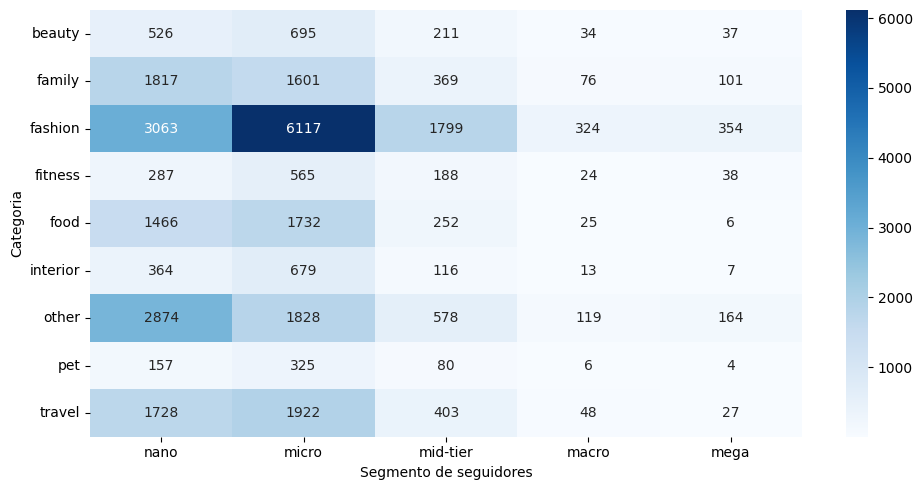

In [9]:
cobertura = (
    base.group_by("inf_category", "bucket_followers")
    .agg(pl.col("username").n_unique().alias("n_perfis"))
    .to_pandas()
    .pivot(index="inf_category", columns="bucket_followers", values="n_perfis")
    .fillna(0).astype(int)
)
cobertura = cobertura[[b for b in ORDEM_BUCKET if b in cobertura.columns]]

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(cobertura, annot=True, fmt="d", cmap="Blues", ax=ax)
# ax.set_title("Número de perfis elegíveis por categoria e porte")
ax.set_xlabel("Segmento de seguidores")
ax.set_ylabel("Categoria")
plt.tight_layout()
plt.savefig("output/fig_cobertura_segmentos.png", dpi=150)

## 4. Engajamento em Nível de Post

- ER Classico por bucket de seguidores

In [10]:
er_bucket = (
    base.group_by("bucket_followers")
    .agg(pl.col("er_classico").median().alias("er_mediano"))
)
er_bucket = er_bucket.to_pandas()
er_bucket["bucket_followers"] = pd.Categorical(er_bucket["bucket_followers"], categories=ORDEM_BUCKET, ordered=True)
er_bucket.sort_values("bucket_followers")

,bucket_followers,er_mediano
4,nano,3.808718
1,micro,2.789235
2,mid-tier,2.447922
0,macro,2.332092
3,mega,2.157625


- ER clssico mediano por categoria de conteúdo

In [11]:
er_categoria = (
    base.group_by("inf_category")
    .agg(pl.col("er_classico").median().alias("er_mediano"))
    .sort("er_mediano", descending=True)
)
er_categoria

inf_category,er_mediano
str,f64
"""travel""",3.728395
"""pet""",3.69026
"""fashion""",3.453456
"""family""",3.26222
"""fitness""",3.060767
"""beauty""",2.900007
"""interior""",2.46131
"""food""",2.454418
"""other""",1.983122


- ER mediano: tabela cruzada de categoria por bucket de seguidores

In [12]:
er_matrix = (
    base.group_by(["inf_category", "bucket_followers"])
    .agg(pl.col("er_classico").median().alias("er_mediano"))
    .to_pandas()
    .pivot(index="inf_category", columns="bucket_followers", values="er_mediano")
)
er_matrix = er_matrix[[b for b in ORDEM_BUCKET if b in er_matrix.columns]]
er_matrix.round(3)

bucket_followers,nano,micro,mid-tier,macro,mega
inf_category,,,,,
beauty,3.427,2.678,2.473,3.034,2.563
family,3.746,2.975,2.832,3.017,2.414
fashion,5.501,3.130,2.621,2.801,2.346
fitness,4.232,3.020,2.190,2.073,2.556
food,3.250,2.132,1.585,0.975,0.521
interior,3.632,2.173,1.688,0.934,0.838
other,2.227,1.660,2.004,1.425,1.654
pet,4.508,3.438,3.587,2.429,2.239
travel,4.794,3.342,2.733,2.192,2.334


- ER mediano por tipo de post e categoria

In [13]:
er_tipo_cat = (
    base.group_by(["inf_category", "post_type"])
    .agg(pl.col("er_classico").median().alias("er_mediano"))
    .sort(["inf_category", "post_type"])
)
er_tipo_cat

inf_category,post_type,er_mediano
str,str,f64
"""beauty""","""carousel""",3.032183
"""beauty""","""image""",2.877346
"""family""","""carousel""",3.407907
"""family""","""image""",3.238273
"""fashion""","""carousel""",3.604723
…,…,…
"""other""","""image""",1.94356
"""pet""","""carousel""",3.964401
"""pet""","""image""",3.66322


### 4.1 Patrocinado vs Não patrocinado

In [14]:
base.group_by("is_sponsored").agg(pl.col("er_classico").median().alias("er_mediano")).sort("is_sponsored")

is_sponsored,er_mediano
bool,f64
false,3.041145
true,2.730474


- Patrocinado vc Não patr. por bucket de seguidores

In [15]:
spons_bucket = (
    base.group_by(["bucket_followers", "is_sponsored"])
    .agg(pl.col("er_classico").median().alias("er_mediano"))
    .to_pandas()
    .pivot(index="bucket_followers", columns="is_sponsored", values="er_mediano")
    .rename(columns={False: "nao_patrocinado", True: "patrocinado"})
)
spons_bucket["diferenca"] = (spons_bucket["nao_patrocinado"] - spons_bucket["patrocinado"]).round(4)
spons_bucket["bucket_followers"] = pd.Categorical(spons_bucket.index, categories=ORDEM_BUCKET, ordered=True)


In [16]:
spons_bucket

is_sponsored,nao_patrocinado,patrocinado,diferenca,bucket_followers
bucket_followers,,,,
macro,2.353320,2.099568,0.2538,macro
mega,2.171035,1.948045,0.2230,mega
micro,2.795379,2.708811,0.0866,micro
mid-tier,2.467360,2.241601,0.2258,mid-tier
nano,3.832033,3.356668,0.4754,nano


- Patrocinado vc Não patr. por categoria

In [17]:
spons_cat = (
    base.group_by(["inf_category", "is_sponsored"])
    .agg(pl.col("er_classico").median().alias("er_mediano"))
    .to_pandas()
    .pivot(index="inf_category", columns="is_sponsored", values="er_mediano")
    .rename(columns={False: "nao_patrocinado", True: "patrocinado"})
)
spons_cat["diferenca"] = (spons_cat["nao_patrocinado"] - spons_cat["patrocinado"]).round(3)
spons_cat.sort_values("diferenca", ascending=False)

is_sponsored,nao_patrocinado,patrocinado,diferenca
inf_category,,,
travel,3.759929,3.093217,0.667
pet,3.715786,3.234153,0.482
interior,2.484910,2.055792,0.429
fitness,3.077630,2.683552,0.394
fashion,3.480024,3.116167,0.364
food,2.477207,2.173034,0.304
other,1.998278,1.733102,0.265
beauty,2.913932,2.696326,0.218
family,3.270635,3.148637,0.122


### 4.2 Distribuição anual de ER

In [18]:
er_anual = (
    base.with_columns(pl.col("data_dt").dt.year().alias("ano"))
    .group_by("ano")
    .agg(pl.col("er_classico").median().alias("er_mediano"))
    .sort("ano")
)
er_anual

ano,er_mediano
i32,f64
2017,2.941176
2018,3.134832
2019,2.775218


## 4.3 ER mediano por bucket

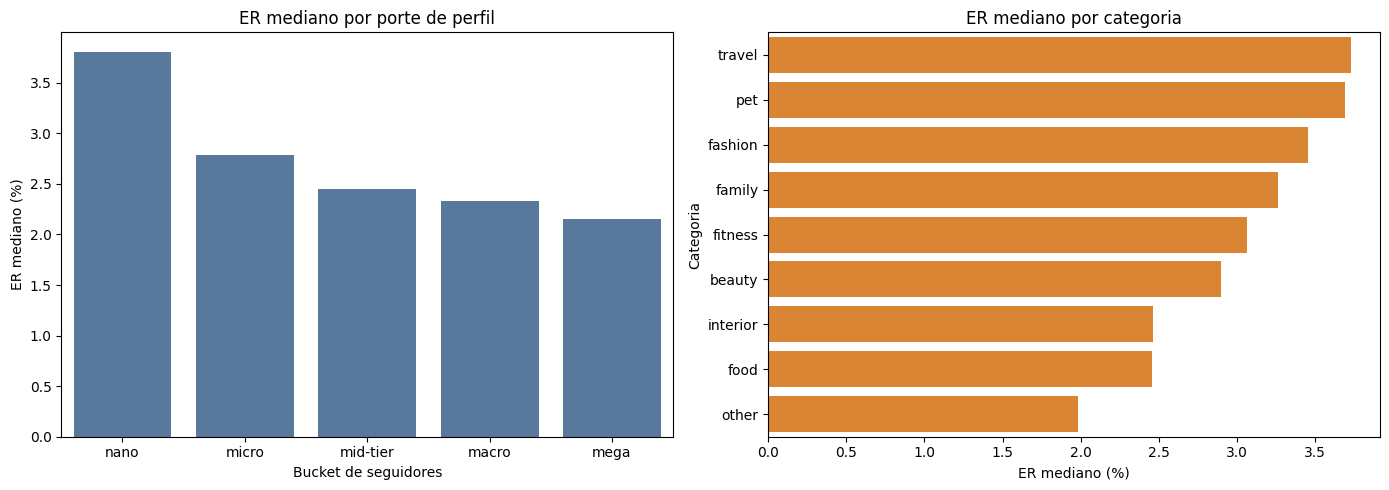

In [19]:
erbucket = (
    base.group_by("bucket_followers")
    .agg(pl.col("er_classico").median().alias("er_mediano"))
    .to_pandas()
)
erbucket["bucket_followers"] = pd.Categorical(
    erbucket["bucket_followers"], categories=ORDEM_BUCKET, ordered=True
)
erbucket = erbucket.sort_values("bucket_followers")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=erbucket, x="bucket_followers", y="er_mediano", ax=axes[0], color="#4C78A8")
axes[0].set_title("ER mediano por porte de perfil")
axes[0].set_xlabel("Bucket de seguidores")
axes[0].set_ylabel("ER mediano (%)")

ercategoria = (
    base.group_by("inf_category")
    .agg(pl.col("er_classico").median().alias("er_mediano"))
    .sort("er_mediano", descending=True)
    .to_pandas()
)
sns.barplot(data=ercategoria, x="er_mediano", y="inf_category", ax=axes[1], color="#F58518")
axes[1].set_title("ER mediano por categoria")
axes[1].set_xlabel("ER mediano (%)")
axes[1].set_ylabel("Categoria")

plt.tight_layout()
plt.savefig("output/fig_er_bucket_categoria.png", dpi=150)

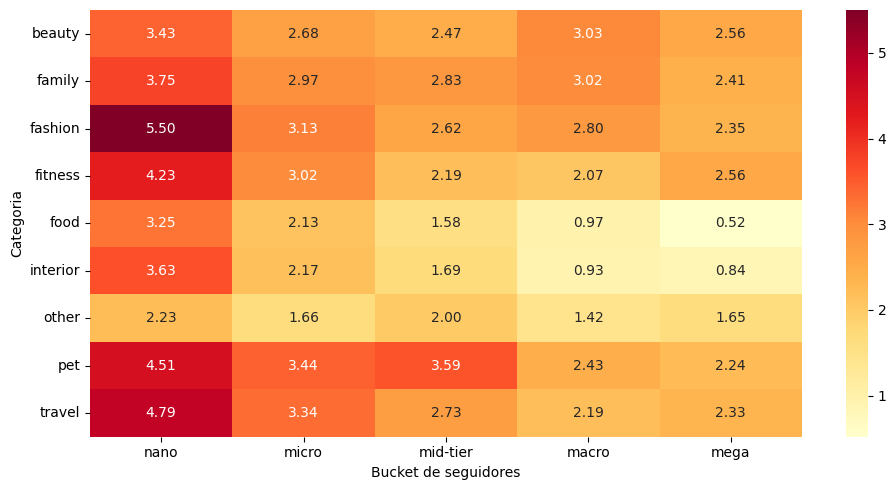

In [20]:
ermatrix = (
    base.group_by("inf_category", "bucket_followers")
    .agg(pl.col("er_classico").median().alias("er_mediano"))
    .to_pandas()
    .pivot(index="inf_category", columns="bucket_followers", values="er_mediano")
)
ermatrix = ermatrix[[b for b in ORDEM_BUCKET if b in ermatrix.columns]].round(2)

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(ermatrix, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax)
# ax.set_title("ER mediano por categoria e porte de perfil")
ax.set_xlabel("Bucket de seguidores")
ax.set_ylabel("Categoria")
plt.tight_layout()
plt.savefig("output/fig_er_heatmap.png", dpi=150)

In [22]:
df_distribuicao = base.select(["bucket_followers","er_classico"]).to_pandas()

df_distribuicao["er_classico_log"] = np.log1p(df_distribuicao["er_classico"])

C:\Users\cruzd\AppData\Local\Temp\ipykernel_25328\3819317032.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


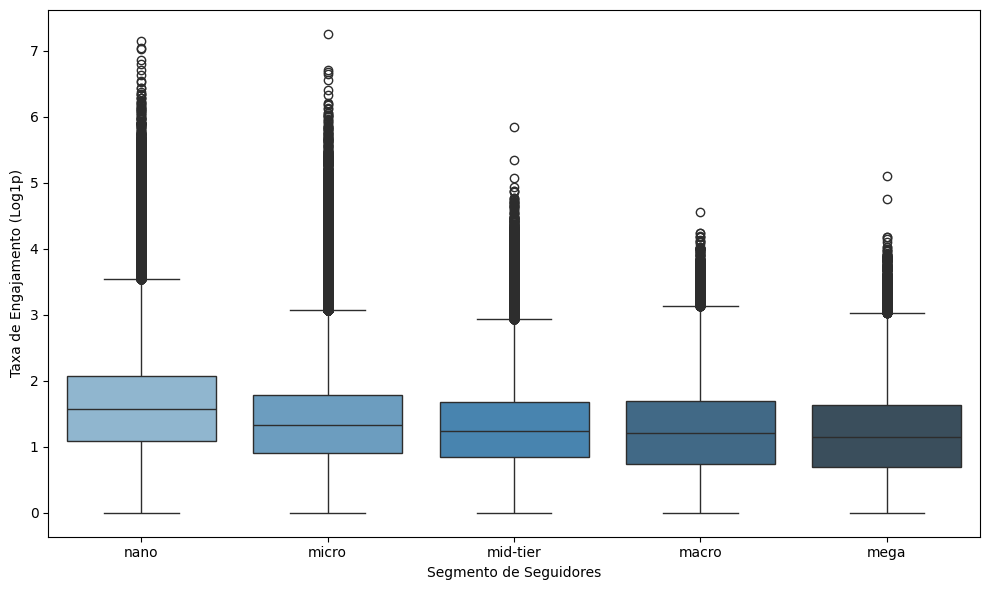

In [28]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_distribuicao, 
    x='bucket_followers', 
    y='er_classico_log', 
    order=ORDEM_BUCKET, 
    palette='Blues_d',
    showfliers=True
)
# plt.title('Distribuição da Taxa de Engajamento por Segmento (escala Log1p)')
plt.xlabel('Segmento de Seguidores')
plt.ylabel('Taxa de Engajamento (Log1p)')
plt.tight_layout()
plt.savefig('output/fig_log_distribuicao_te.png', dpi=300)
plt.show()

C:\Users\cruzd\AppData\Local\Temp\ipykernel_25328\113134353.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


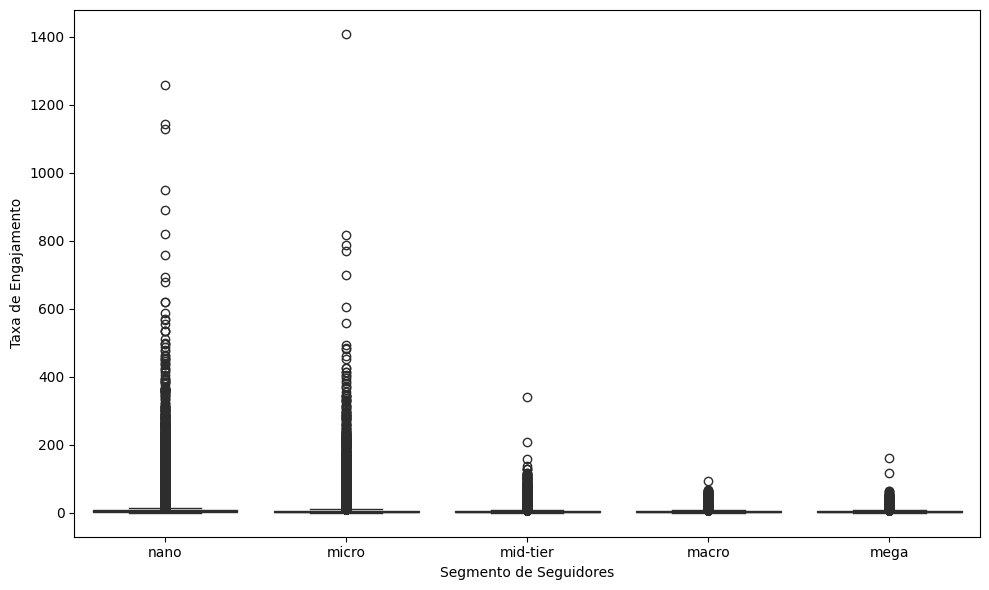

In [29]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_distribuicao, 
    x='bucket_followers', 
    y='er_classico', 
    order=ORDEM_BUCKET, 
    palette='Blues_d',
    showfliers=True
)
# plt.title('Distribuição da Taxa de Engajamento por Segmento (escala Log1p)')
plt.xlabel('Segmento de Seguidores')
plt.ylabel('Taxa de Engajamento')
plt.tight_layout()
plt.savefig('output/fig_distribuicao_te.png', dpi=300)
plt.show()

In [25]:
df_distribuicao.er_classico.describe()

count    8.897233e+06
mean     4.327969e+00
std      5.291196e+00
min      0.000000e+00
25%      1.569472e+00
50%      3.020962e+00
75%      5.491529e+00
max      1.408704e+03
Name: er_classico, dtype: float64

In [32]:
base.filter(pl.col("er_classico") > 10).sort(by="er_classico",descending=True)

post_id,username,inf_category,followers,followees,posts_total,is_verified,data,timestamp_unix,likes,comments_count,post_type,n_imagens,aspect_ratio,is_sponsored,n_hashtags,n_usertags,caption_len,has_location,accessibility,perfil_completo_lookup,data_dt,er_classico,er_weighted,bucket_followers,er_bucket_industria,er_bucket_percentil,er_media_bucket,er_std_bucket,thresh_low,thresh_high,adapted_bucket
str,str,str,i64,i64,i64,bool,str,i64,i64,i64,str,i64,f64,bool,i64,i64,i64,bool,str,bool,date,f64,f64,str,str,str,f64,f64,f64,f64,str
"""BrA8XTGhFeA""","""gregnoire""","""other""",57650,672,1540,true,"""2018-12-05""",1544032420,812118,0,"""image""",1,1.04,true,1,2,420,false,"""""",true,2018-12-05,1408.70425,1408.70425,"""micro""","""VIRAL""","""Q4""",3.861336,4.545421,-0.684085,8.406757,"""VIRAL"""
"""BuaVItFFB-8""","""chrisvalentine17""","""other""",3883,477,503,false,"""2019-02-28""",1551326719,48857,0,"""image""",1,0.8,false,23,3,353,true,"""""",true,2019-02-28,1258.228174,1258.228174,"""nano""","""VIRAL""","""Q4""",5.3779,6.556056,-1.178156,11.933956,"""VIRAL"""
"""Bti7t6SnMFm""","""nanikiiireads""","""other""",1155,341,242,false,"""2019-02-06""",1549467899,13216,0,"""image""",1,1.0,false,26,2,793,false,"""""",true,2019-02-06,1144.242424,1144.242424,"""nano""","""VIRAL""","""Q4""",5.3779,6.556056,-1.178156,11.933956,"""VIRAL"""
"""BjfUY8mgrJv""","""melaninrules_""","""other""",3046,276,1013,false,"""2018-06-01""",1527871780,34393,0,"""image""",1,0.962,false,16,0,147,false,"""""",true,2018-06-01,1129.120158,1129.120158,"""nano""","""VIRAL""","""Q4""",5.3779,6.556056,-1.178156,11.933956,"""VIRAL"""
"""BrvVGwrlpnC""","""gronkhusky""","""pet""",1674,940,321,false,"""2018-12-23""",1545588895,15893,0,"""image""",1,0.8,false,28,1,399,true,"""""",true,2018-12-23,949.402628,949.402628,"""nano""","""VIRAL""","""Q4""",5.3779,6.556056,-1.178156,11.933956,"""VIRAL"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""BXkvLZYhkgU""","""thetattooedhusband""","""food""",40319,5671,1341,false,"""2017-08-09""",1502283793,4032,0,"""image""",1,0.818,false,30,1,559,true,"""""",true,2017-08-09,10.000248,10.000248,"""micro""","""VIRAL""","""Q4""",3.861336,4.545421,-0.684085,8.406757,"""HIGH"""
"""BoWIqV6lmry""","""miakhalifa""","""fashion""",11091509,441,1632,true,"""2018-09-30""",1538301059,1109177,0,"""image""",1,0.975,false,0,3,255,true,"""""",true,2018-09-30,10.000235,10.000235,"""mega""","""VIRAL""","""Q4""",3.086237,3.261621,-0.175384,6.347859,"""VIRAL"""
"""Bm_Uwa4HDRI""","""ronkeraji""","""beauty""",259036,860,1081,true,"""2018-08-27""",1535388165,25904,0,"""image""",1,0.807,false,0,13,431,true,"""""",true,2018-08-27,10.000154,10.000154,"""mid-tier""","""VIRAL""","""Q4""",3.460533,3.608242,-0.147709,7.068775,"""HIGH"""


In [33]:
base.filter(pl.col("username") == "gregnoire").sort(by="er_classico",descending=True)

post_id,username,inf_category,followers,followees,posts_total,is_verified,data,timestamp_unix,likes,comments_count,post_type,n_imagens,aspect_ratio,is_sponsored,n_hashtags,n_usertags,caption_len,has_location,accessibility,perfil_completo_lookup,data_dt,er_classico,er_weighted,bucket_followers,er_bucket_industria,er_bucket_percentil,er_media_bucket,er_std_bucket,thresh_low,thresh_high,adapted_bucket
str,str,str,i64,i64,i64,bool,str,i64,i64,i64,str,i64,f64,bool,i64,i64,i64,bool,str,bool,date,f64,f64,str,str,str,f64,f64,f64,f64,str
"""BrA8XTGhFeA""","""gregnoire""","""other""",57650,672,1540,true,"""2018-12-05""",1544032420,812118,0,"""image""",1,1.04,true,1,2,420,false,"""""",true,2018-12-05,1408.70425,1408.70425,"""micro""","""VIRAL""","""Q4""",3.861336,4.545421,-0.684085,8.406757,"""VIRAL"""
"""BnFg6zDhJpA""","""gregnoire""","""other""",57650,672,1540,true,"""2018-08-30""",1535595868,11455,0,"""image""",1,1.0,false,0,2,4,false,"""""",true,2018-08-30,19.869905,19.869905,"""micro""","""VIRAL""","""Q4""",3.861336,4.545421,-0.684085,8.406757,"""VIRAL"""
"""BtrTvR_hjhd""","""gregnoire""","""other""",57650,672,1540,true,"""2019-02-09""",1549748928,10226,0,"""image""",1,1.0,false,0,2,7,false,"""""",true,2019-02-09,17.738075,17.738075,"""micro""","""VIRAL""","""Q4""",3.861336,4.545421,-0.684085,8.406757,"""VIRAL"""
"""BlmAPmAhClq""","""gregnoire""","""other""",57650,672,1540,true,"""2018-07-24""",1532391066,8591,0,"""image""",1,1.0,false,0,2,76,false,"""""",true,2018-07-24,14.901995,14.901995,"""micro""","""VIRAL""","""Q4""",3.861336,4.545421,-0.684085,8.406757,"""VIRAL"""
"""Bo5bk1_h_xA""","""gregnoire""","""other""",57650,672,1540,true,"""2018-10-14""",1539485381,7961,0,"""image""",1,0.818,false,1,2,30,true,"""""",true,2018-10-14,13.809193,13.809193,"""micro""","""VIRAL""","""Q4""",3.861336,4.545421,-0.684085,8.406757,"""VIRAL"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""BfwvFpFh0lJ""","""gregnoire""","""other""",57650,672,1540,true,"""2018-03-01""",1519866268,514,0,"""image""",1,1.5,true,2,0,439,true,"""""",true,2018-03-01,0.891587,0.891587,"""micro""","""LOW""","""Q1""",3.861336,4.545421,-0.684085,8.406757,"""MEDIUM"""
"""Bab3yxAhEbQ""","""gregnoire""","""other""",57650,672,1540,false,"""2017-10-19""",1508428771,510,0,"""image""",1,1.129,true,2,0,383,true,"""""",true,2017-10-19,0.884649,0.884649,"""micro""","""LOW""","""Q1""",3.861336,4.545421,-0.684085,8.406757,"""MEDIUM"""
"""Bc7pSqcBF7e""","""gregnoire""","""other""",57650,672,1540,true,"""2017-12-20""",1513789877,472,0,"""carousel""",2,1.301,true,2,3,944,true,"""Image may contain: one or more…",true,2017-12-20,0.818734,0.818734,"""micro""","""LOW""","""Q1""",3.861336,4.545421,-0.684085,8.406757,"""MEDIUM"""


In [34]:
base.sort(by='er_classico')

post_id,username,inf_category,followers,followees,posts_total,is_verified,data,timestamp_unix,likes,comments_count,post_type,n_imagens,aspect_ratio,is_sponsored,n_hashtags,n_usertags,caption_len,has_location,accessibility,perfil_completo_lookup,data_dt,er_classico,er_weighted,bucket_followers,er_bucket_industria,er_bucket_percentil,er_media_bucket,er_std_bucket,thresh_low,thresh_high,adapted_bucket
str,str,str,i64,i64,i64,bool,str,i64,i64,i64,str,i64,f64,bool,i64,i64,i64,bool,str,bool,date,f64,f64,str,str,str,f64,f64,f64,f64,str
"""BqE-q4LlPC0""","""1stoftheday""","""other""",4651,4624,1954,false,"""2018-11-12""",1542020363,0,0,"""image""",1,1.0,false,0,0,0,false,"""""",true,2018-11-12,0.0,0.0,"""nano""","""LOW""","""Q1""",5.3779,6.556056,-1.178156,11.933956,"""MEDIUM"""
"""BqLci3sl3Q_""","""1stoftheday""","""other""",4651,4624,1954,false,"""2018-11-14""",1542237352,0,0,"""image""",1,1.0,false,0,0,0,false,"""""",true,2018-11-14,0.0,0.0,"""nano""","""LOW""","""Q1""",5.3779,6.556056,-1.178156,11.933956,"""MEDIUM"""
"""BqLckBFlICb""","""1stoftheday""","""other""",4651,4624,1954,false,"""2018-11-14""",1542237362,0,0,"""image""",1,1.0,false,0,0,0,false,"""""",true,2018-11-14,0.0,0.0,"""nano""","""LOW""","""Q1""",5.3779,6.556056,-1.178156,11.933956,"""MEDIUM"""
"""BpkMO9slACm""","""24jazzy_""","""travel""",5337,374,846,false,"""2018-10-30""",1540920178,0,0,"""image""",1,1.0,false,0,0,0,false,"""""",true,2018-10-30,0.0,0.0,"""nano""","""LOW""","""Q1""",5.3779,6.556056,-1.178156,11.933956,"""MEDIUM"""
"""Bpj9ipLldEN""","""24jazzy_""","""travel""",5337,374,846,false,"""2018-10-30""",1540912475,0,0,"""image""",1,1.0,false,0,0,0,false,"""""",true,2018-10-30,0.0,0.0,"""nano""","""LOW""","""Q1""",5.3779,6.556056,-1.178156,11.933956,"""MEDIUM"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""BrvVGwrlpnC""","""gronkhusky""","""pet""",1674,940,321,false,"""2018-12-23""",1545588895,15893,0,"""image""",1,0.8,false,28,1,399,true,"""""",true,2018-12-23,949.402628,949.402628,"""nano""","""VIRAL""","""Q4""",5.3779,6.556056,-1.178156,11.933956,"""VIRAL"""
"""BjfUY8mgrJv""","""melaninrules_""","""other""",3046,276,1013,false,"""2018-06-01""",1527871780,34393,0,"""image""",1,0.962,false,16,0,147,false,"""""",true,2018-06-01,1129.120158,1129.120158,"""nano""","""VIRAL""","""Q4""",5.3779,6.556056,-1.178156,11.933956,"""VIRAL"""
"""Bti7t6SnMFm""","""nanikiiireads""","""other""",1155,341,242,false,"""2019-02-06""",1549467899,13216,0,"""image""",1,1.0,false,26,2,793,false,"""""",true,2019-02-06,1144.242424,1144.242424,"""nano""","""VIRAL""","""Q4""",5.3779,6.556056,-1.178156,11.933956,"""VIRAL"""


## 5. Classificações de engajamento por post

- Distribuição do adapted_bucket

In [42]:
ab_dist = (
    base.group_by("adapted_bucket")
    .agg(pl.len().alias("n_posts"))
    .with_columns((pl.col("n_posts") / base.shape[0] * 100).round(2).alias("pct"))
    .sort("n_posts", descending=True)
)
ab_dist

adapted_bucket,n_posts,pct
str,u32,f64
"""MEDIUM""",8090033,90.93
"""HIGH""",544857,6.12
"""VIRAL""",262343,2.95


In [44]:
ab_cat = (
    base.group_by(["inf_category", "adapted_bucket"])
    .agg(pl.len().alias("n"))
    .to_pandas()
    .pivot(index="inf_category", columns="adapted_bucket", values="n")
    .fillna(0)
)
order_ab = ["LOW", "MEDIUM", "HIGH", "VIRAL"]
ab_cat = ab_cat[[c for c in order_ab if c in ab_cat.columns]]
ab_cat_pct = ab_cat.div(ab_cat.sum(axis=1), axis=0).round(4)
ab_cat_pct

adapted_bucket,MEDIUM,HIGH,VIRAL
inf_category,,,
beauty,0.9095,0.0594,0.0311
family,0.8995,0.0675,0.0330
fashion,0.8853,0.0781,0.0366
fitness,0.9202,0.0567,0.0231
food,0.9557,0.0297,0.0146
interior,0.9528,0.0312,0.0160
other,0.9423,0.0362,0.0215
pet,0.9022,0.0646,0.0332
travel,0.8874,0.0786,0.0340


## 6. Correlações de caracteristicas do post com er classico

In [46]:
variaveis = ["n_hashtags", "caption_len", "n_usertags", "aspect_ratio", "n_imagens"]
df_corr = base.select(["er_classico"] + variaveis).drop_nulls().to_pandas()

resultados = []
for var in variaveis:
    rho_spearman, pval_s = spearmanr(df_corr["er_classico"], df_corr[var])
    rho_pearson, pval_p = pearsonr(df_corr["er_classico"], df_corr[var])
    resultados.append({
        "variavel": var, 
        "spearman_rho": round(rho_spearman, 4),
        "pearson_r": round(rho_pearson, 4)
    })

pd.DataFrame(resultados).sort_values("spearman_rho", key=abs, ascending=False)

,variavel,spearman_rho,pearson_r
2,n_usertags,0.1611,0.0948
3,aspect_ratio,-0.1237,-0.0526
0,n_hashtags,-0.0337,0.0135
1,caption_len,-0.0165,-0.0000
4,n_imagens,0.0152,0.0075


## 7. Engajamento e estabilidade em nível de Perfil

Agora a analise sai do nível de Posts e entra no nível de Perfil

O CV (coeficiente de variação do ER) possui duas versões:
- cv_base : calculado sobre todos os posts do período 2017-2019 com followers > 0. 
- cv_core : calculado sobre o subconjunto com comments_count > 0

A analise agora é feita sobre cv_base, na seção 8 comparamos cv_base com cv_core

In [47]:
cv_base.select(["er_media", "er_std", "er_mediana", "cv"]).describe()

statistic,er_media,er_std,er_mediana,cv
str,f64,f64,f64,f64
"""count""",33127.0,33127.0,33127.0,33127.0
"""null_count""",0.0,0.0,0.0,0.0
"""mean""",4.450271,2.369813,3.978933,0.564165
"""std""",3.688373,3.188322,3.342173,0.375012
"""min""",0.004463,0.002122,0.0,0.043866
"""25%""",2.044802,0.975933,1.748315,0.368297
"""50%""",3.483354,1.665737,3.084973,0.484325
"""75%""",5.783202,2.7928,5.215074,0.65344
"""max""",63.833697,106.555885,63.761468,14.175452


- Perfis com menos CV

In [48]:
cv_base.sort("cv").head(10)

username,n_posts_validos,er_media,er_std,er_mediana,cv
str,u32,f64,f64,f64,f64
"""marta__lu""",232,1.225535,0.053759,1.218085,0.043866
"""mr_youngblood_fitness""",300,4.651766,0.277315,4.622572,0.059615
"""leah_stauffer""",280,3.744877,0.237283,3.725429,0.063362
"""chocobi8011""",300,3.122739,0.201389,3.135649,0.064491
"""kathryneisman""",299,1.692156,0.114225,1.680569,0.067503
"""xo.rachelpitzel""",300,3.652895,0.25204,3.628454,0.068997
"""thefashionheist""",300,2.796035,0.205464,2.765934,0.073484
"""s.jones.fitness""",300,1.031638,0.076434,1.040656,0.07409
"""alwayscreatingblog""",300,1.59118,0.126409,1.566522,0.079444


- Perfis com maior CV

In [49]:
cv_base.sort("cv",descending=True).head(10)

username,n_posts_validos,er_media,er_std,er_mediana,cv
str,u32,f64,f64,f64,f64
"""chrisvalentine17""",299,5.130933,72.733291,0.746845,14.175452
"""gossipingheifers""",300,2.584626,26.158841,0.83499,10.12094
"""_cm0""",300,2.110542,17.455112,0.901402,8.270439
"""gregnoire""",295,10.026766,81.762902,4.700781,8.154464
"""namastejenay""",300,6.480908,52.837254,1.800567,8.152755
"""paxtonvisuals""",300,7.316481,54.84753,2.309723,7.496436
"""karimjones""",300,7.455008,51.734231,3.326235,6.939527
"""the_moabs""",300,2.00617,13.865917,0.787712,6.911635
"""eluminamagazine""",106,1.914957,13.08026,0.464396,6.830578


- CV mediano por categoria

In [50]:
cv_base_pd = cv_base.to_pandas()

lookup_perfil = (
    base.group_by("username")
    .agg([
        pl.col("inf_category").first(),
        pl.col("bucket_followers").first()
    ])
    .to_pandas()
)

cv_base_enriquecido = cv_base_pd.merge(lookup_perfil, on="username", how="left")

cv_cat = (
    cv_base_enriquecido.groupby("inf_category")["cv"]
    .median()
    .reset_index()
    .rename(columns={"cv": "cv_mediano"})
    .sort_values("cv_mediano")
)
cv_cat

,inf_category,cv_mediano
7,pet,0.397835
8,travel,0.434508
2,fashion,0.441398
4,food,0.484205
1,family,0.492273
3,fitness,0.495795
5,interior,0.531385
0,beauty,0.545397
6,other,0.628371


- CV mediano por bucket de seguidores

In [51]:
cv_bucket = (
    cv_base_enriquecido.groupby("bucket_followers")["cv"]
    .median()
    .reset_index()
    .rename(columns={"cv": "cv_mediano"})
)
cv_bucket["bucket_followers"] = pd.Categorical(cv_bucket["bucket_followers"], categories=ORDEM_BUCKET, ordered=True)
cv_bucket.sort_values("bucket_followers")

,bucket_followers,cv_mediano
4,nano,0.469664
2,micro,0.487707
3,mid-tier,0.493220
0,macro,0.536914
1,mega,0.586281


- Distribuição de CV base

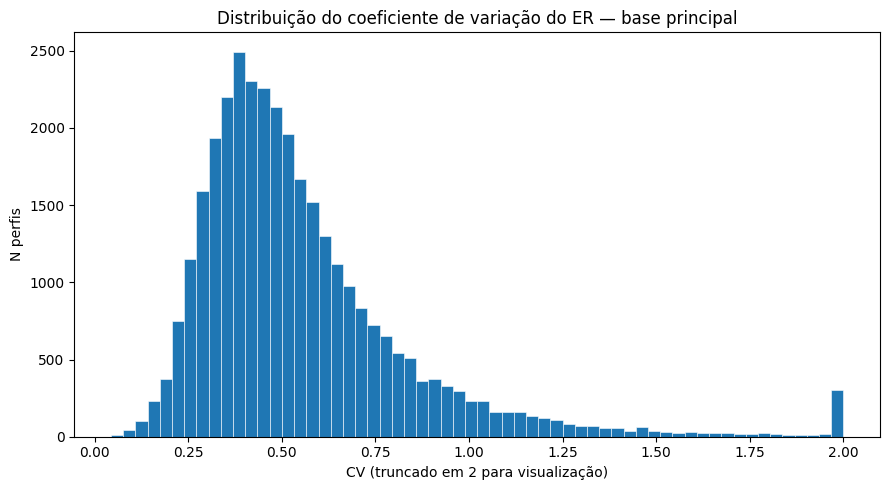

In [55]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(cv_base_enriquecido["cv"].clip(upper=2), bins=60, edgecolor="white", linewidth=0.4)
ax.set_xlabel("CV (truncado em 2 para visualização)")
ax.set_ylabel("N perfis")
ax.set_title("Distribuição do coeficiente de variação do ER — base principal")
plt.tight_layout()
plt.show()

## 8. Comparação cv_base vc cv_core

Verifica se o CV calculado sobre todos os posts (`cv_base`) e o calculado apenas sobre posts com `comments_count > 0`(`cv_core`) são concordantes

In [56]:
cv_comparacao = cv_base_pd[["username", "cv"]].merge(
    cv_core.to_pandas()[["username", "cv"]],
    on="username", how="inner",
    suffixes=("_base", "_core")
)

In [58]:
rho_cv, _ = spearmanr(cv_comparacao["cv_base"], cv_comparacao["cv_core"])
dif_mediana = (cv_comparacao["cv_base"] - cv_comparacao["cv_core"]).abs().median()
n_concordantes = (cv_comparacao["cv_base"].round(1) == cv_comparacao["cv_core"].round(1)).mean()

print(f"Perfis em comum: {len(cv_comparacao)}")
print(f"Correlação de Spearman (cv_base vs cv_core): {rho_cv:.4f}")
print(f"Diferença absoluta mediana: {dif_mediana:.4f}")
print(f"Concordância a 1 casa decimal (%): {n_concordantes*100:.2f}%")

Perfis em comum: 32646
Correlação de Spearman (cv_base vs cv_core): 0.8219
Diferença absoluta mediana: 0.0661
Concordância a 1 casa decimal (%): 37.91%


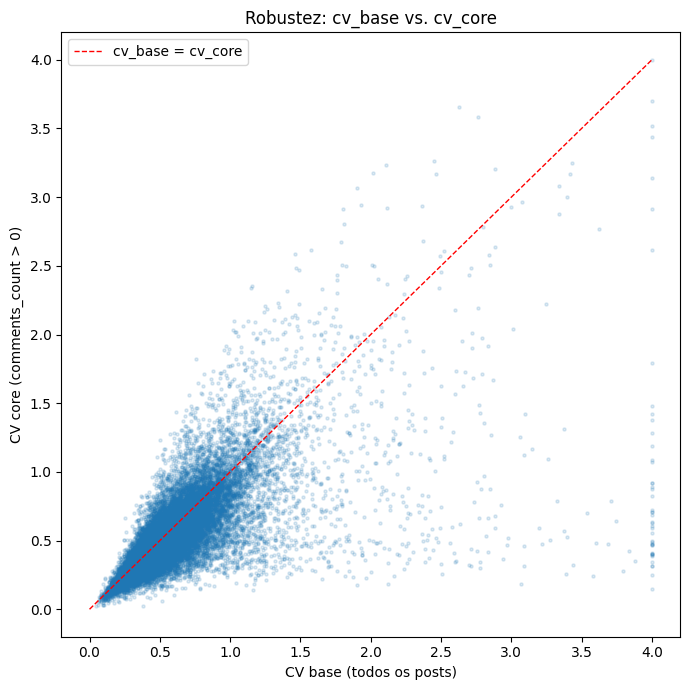

In [61]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(cv_comparacao["cv_base"].clip(upper=4),
           cv_comparacao["cv_core"].clip(upper=4),
           alpha=0.15, s=5, rasterized=True)
ax.plot([0, 4], [0, 4], "r--", linewidth=1, label="cv_base = cv_core")
ax.set_xlabel("CV base (todos os posts)")
ax.set_ylabel("CV core (comments_count > 0)")
ax.set_title("Robustez: cv_base vs. cv_core")
ax.legend()
plt.tight_layout()
plt.show()

## 9. Estabilidade ao longo do tempo
O CV anual permite verificar se a instabilidade do ER é uniforme ao longo dos anos.

- CV base

In [62]:
cv_anual_base.group_by("ano").agg(
    pl.col("cv").median().alias("cv_mediano"),
    pl.col("cv").mean().alias("cv_medio"),
    pl.len().alias("n_perfis_ano")
).sort("ano")

ano,cv_mediano,cv_medio,n_perfis_ano
i32,f64,f64,u32
2017,0.384494,0.438583,19900
2018,0.426486,0.492475,32488
2019,0.39746,0.464179,31725


- CV core

In [63]:
cv_anual_core.group_by("ano").agg(
    pl.col("cv").median().alias("cv_mediano"),
    pl.len().alias("n_perfis_ano")
).sort("ano")

ano,cv_mediano,n_perfis_ano
i32,f64,u32
2017,0.347259,14384
2018,0.384529,29664
2019,0.366686,15254


## 10. Síntese dos Resultados

**Base**: 8,89M posts, 33.149 perfis, jan/2017–mai/2019. Posts de imagem: 87,5%. Patrocinados: 5,9%.

**Engajamento por tamanho**: padrão nano > micro > mid-tier > macro > mega robusto em todas as
categorias. Nano apresenta ER mediano superior ao mega (3,81% vs. 2,16%).

**Engajamento por categoria**: travel e pet lideram; food e other têm menor ER.
Carousel supera image sistematicamente.

**Patrocínio**: redução de ER em 100% das combinações bucket × categoria.
Maior impacto em travel (−0,67) e em perfis nano (−0,47).

**Estabilidade (cv_base)**: CV mediano = 0,484. Distribuição assimétrica.
Mais estáveis: pet (0,40), travel (0,43). Menos estáveis: beauty (0,55), other (0,63).
Instabilidade cresce com o tamanho do perfil.

**Robustez do CV**: cv_core produz medianas inferiores (exclusão de posts sem comentários
remove outliers de baixo engajamento), mas a ordenação entre categorias e buckets é preservada.

**Temporalidade**: CV levemente mais alto em 2018 (maior volume de posts na amostra),
sem tendência estrutural no período.

## Encadeamento

Essa etapa alimenta diretamente o Perfil de Qualificação da audiencia(`perfil_qualificacao.ipynb`), especialmente na construção do score